# Experimental implementation Multiscale SpaCo 


In [1]:
# Imports 
# Imports and Data loading 

import numpy as np
import pandas as pd
import sys
import anndata as ad
from scipy.sparse import csr_matrix



# Dataformats (Passive loading, sparse mats, path orga)  
import scanpy as sc     
from pathlib import Path
import scipy.sparse as sp
import json


# Visualization and ROI selection: 
import matplotlib.pyplot as plt
from PIL import Image
import napari
from matplotlib.path import Path as MplPath # For Polygon cutout 
from scipy.ndimage import binary_dilation   

# import Napari wrapper functions: 
sys.path.append(r"C:\Users\justu\Desktop\Science_Coding_Directory\Metabolomics_Collaboration\Scripts\Import_Scripts")
from Napari_wrapper2 import *

# import Plotting functions:
sys.path.append(r"C:\Users\justu\Desktop\Science_Coding_Directory\Metabolomics_Collaboration\Scripts\Import_Scripts")
from Plotting_functions import *


In [ ]:
# Load the data: 
path = r"C:\Users\justu\Desktop\Science_Coding_Directory\Metabolomics_Collaboration\Data\Maldi_IMS\spatial_pyramid.npz"
path_2 = r"C:\Users\justu\Desktop\Science_Coding_Directory\Metabolomics_Collaboration\Data\Maldi_IMS\second_layer_pyramid.npz"
path_3 = r"C:\Users\justu\Desktop\Science_Coding_Directory\Metabolomics_Collaboration\Data\Maldi_IMS\bottom_layer_pyramid.npz"
data = np.load(path, allow_pickle=False)
pyramid = {int(k): data[k] for k in data.files}

# Last layer: 
data2 = np.load(path_2, allow_pickle=True)
data3 = np.load(path_3, allow_pickle=True)



In [ ]:

def flatten_spatial_features(X, to_sparse=False):
    """
    Convert an (n, m, f) tensor into:
        coords   : (k, 2) coordinate array
        features : (k, f) feature matrix

    Only keeps pixels whose feature vector is NOT entirely NaN.
    This preserves exact row-to-row correspondence between coords and features.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (n, m, f)
    to_sparse : bool, default=False
        If True, return features as scipy.sparse.csr_matrix.
        Remaining NaNs are converted to 0 before sparsification.

    Returns
    -------
    coords : np.ndarray
        Shape (k, 2)
    features : np.ndarray or scipy.sparse.csr_matrix
        Shape (k, f)
    """
    n, m, f = X.shape

    coords_list = []
    features_list = []

    for i in range(n):
        for j in range(m):
            vec = X[i, j, :]
            if not np.all(np.isnan(vec)):   # keep only if not all entries are NaN
                coords_list.append([i, j])
                features_list.append(vec)

    coords = np.array(coords_list, dtype=int)
    features = np.array(features_list)

    if to_sparse:
        features = csr_matrix(np.nan_to_num(features, nan=0.0))

    return coords, features


In [21]:
def flatten_spatial_features_auto(
    X,
    density_threshold=0.6,
    verbose=True,
    sparse_format="csr"
):
    """
    Flatten a spatial tensor X of shape (n, m, f) into

        coords   : (k, 2) integer coordinate array
        features : (k, f) dense ndarray OR sparse matrix

    Only pixels whose feature vector is not entirely NaN are kept.

    The function first scans the data without building a dense flattened
    feature matrix. It estimates the density of the flattened output and
    then decides whether to return a dense matrix or a sparse matrix.

    IMPORTANT
    ---------
    This function avoids creating an unnecessary dense flattened copy.

    Parameters
    ----------
    X : np.ndarray
        Input tensor of shape (n, m, f).
    density_threshold : float, default=0.8
        If output density >= density_threshold, return dense features.
        If output density < density_threshold, return sparse features.
    verbose : bool, default=True
        If True, print diagnostics.
    sparse_format : str, default="csr"
        Sparse format to return if sparse output is chosen.
        Supported: "csr", "coo", "csc"

    Returns
    -------
    coords : np.ndarray
        Array of shape (k, 2), where each row is [i, j].
    features : np.ndarray or scipy.sparse matrix
        Flattened feature matrix of shape (k, f).
    is_dense : bool
        True if dense output was returned, False if sparse output.
    density : float
        Density of the flattened feature matrix after NaN -> 0 treatment.

    Notes
    -----
    - Rows corresponding to pixels with all-NaN feature vectors are dropped.
    - Remaining NaNs are treated as 0 in the output.
    - Density is computed as:
            nnz / (k * f)
      where nnz counts nonzero entries after NaN -> 0 treatment.
    """

    if not isinstance(X, np.ndarray):
        raise TypeError("X must be a numpy ndarray.")
    if X.ndim != 3:
        raise ValueError("X must have shape (n, m, f).")

    n, m, f = X.shape

    # ------------------------------------------------------------
    # First pass:
    # count valid pixels and nnz of the eventual flattened matrix
    # without materializing it.
    # ------------------------------------------------------------
    k = 0
    nnz = 0

    for i in range(n):
        for j in range(m):
            vec = X[i, j, :]

            # Keep only if not all NaN
            if not np.all(np.isnan(vec)):
                k += 1

                # Count nonzero entries after NaN -> 0 treatment
                # So: count entries that are both not NaN and not zero
                nnz += np.count_nonzero((~np.isnan(vec)) & (vec != 0))

    if k == 0:
        coords = np.empty((0, 2), dtype=int)
        if verbose:
            print("No valid pixels found (all feature vectors are all-NaN).")
        if sparse_format == "csr":
            features = csr_matrix((0, f), dtype=X.dtype)
        elif sparse_format == "coo":
            features = sp.coo_matrix((0, f), dtype=X.dtype)
        elif sparse_format == "csc":
            features = sp.csc_matrix((0, f), dtype=X.dtype)
        else:
            raise ValueError("sparse_format must be one of: 'csr', 'coo', 'csc'")
        return coords, features, False, 0.0

    total = k * f
    density = nnz / total
    is_dense = density >= density_threshold

    if verbose:
        print(f"Original tensor shape: {X.shape}")
        print(f"Valid spatial positions kept: {k}")
        print(f"Flattened feature shape: ({k}, {f})")
        print(f"Nonzeros after NaN->0: {nnz}")
        print(f"Density: {density:.6f}")
        print(f"Treat as dense: {is_dense}")

    # ------------------------------------------------------------
    # Second pass:
    # build only the chosen representation
    # ------------------------------------------------------------
    coords = np.empty((k, 2), dtype=int)

    if is_dense:
        features = np.zeros((k, f), dtype=X.dtype)

        row = 0
        for i in range(n):
            for j in range(m):
                vec = X[i, j, :]
                if not np.all(np.isnan(vec)):
                    coords[row] = [i, j]
                    features[row, :] = np.nan_to_num(vec, nan=0.0)
                    row += 1

    else:
        row_idx = []
        col_idx = []
        values = []

        row = 0
        for i in range(n):
            for j in range(m):
                vec = X[i, j, :]
                if not np.all(np.isnan(vec)):
                    coords[row] = [i, j]

                    valid_mask = (~np.isnan(vec)) & (vec != 0)
                    cols = np.nonzero(valid_mask)[0]

                    if cols.size > 0:
                        row_idx.extend([row] * cols.size)
                        col_idx.extend(cols.tolist())
                        values.extend(vec[cols].tolist())

                    row += 1

        features = sp.coo_matrix(
            (values, (row_idx, col_idx)),
            shape=(k, f)
        )

        if sparse_format == "csr":
            features = features.tocsr()
        elif sparse_format == "csc":
            features = features.tocsc()
        elif sparse_format == "coo":
            pass
        else:
            raise ValueError("sparse_format must be one of: 'csr', 'coo', 'csc'")

    return coords, features, is_dense, density

In [22]:
X0 = data3['arr_0'].item()[0]
X1 = data2['arr_0'].item()[1]
X2 = pyramid[2]
X3 = pyramid[3]
X4 = pyramid[4]

coords_0, features_0, _, _ = flatten_spatial_features_auto(X0)
coords_1, features_1, _, _ = flatten_spatial_features_auto(X1)
coords_2, features_2, _, _ = flatten_spatial_features_auto(X2)
coords_3, features_3, _, _ = flatten_spatial_features_auto(X3)
coords_4, features_4, _, _ = flatten_spatial_features_auto(X4)

Original tensor shape: (787, 713, 621)
Valid spatial positions kept: 269511
Flattened feature shape: (269511, 621)
Nonzeros after NaN->0: 63170846
Density: 0.377441
Treat as dense: False
Original tensor shape: (393, 356, 621)
Valid spatial positions kept: 67453
Flattened feature shape: (67453, 621)
Nonzeros after NaN->0: 24585173
Density: 0.586922
Treat as dense: False
Original tensor shape: (196, 178, 621)
Valid spatial positions kept: 16906
Flattened feature shape: (16906, 621)
Nonzeros after NaN->0: 8205177
Density: 0.781548
Treat as dense: True
Original tensor shape: (98, 89, 621)
Valid spatial positions kept: 4247
Flattened feature shape: (4247, 621)
Nonzeros after NaN->0: 2383045
Density: 0.903563
Treat as dense: True
Original tensor shape: (49, 44, 621)
Valid spatial positions kept: 1072
Flattened feature shape: (1072, 621)
Nonzeros after NaN->0: 638864
Density: 0.959670
Treat as dense: True


---
# 1. Full Algorithm 
1.1 Helper functions  

In [23]:
from dataclasses import dataclass
from typing import List, Optional, Tuple, Union
from scipy.sparse.linalg import LinearOperator, lobpcg
from scipy.linalg import cholesky, eigh
from scipy.spatial import cKDTree


In [24]:
ArrayLike2D = Union[np.ndarray, sp.spmatrix]


# ============================================================
# Data container
# ============================================================

@dataclass
class SpaCoLevel:
    """
    One spatial level.

    Parameters
    ----------
    coords : np.ndarray
        Shape (n, 2). Row i contains the x,y coordinate of spot i.
        These are the only valid spots at this level.
    Y : np.ndarray or scipy.sparse matrix
        Shape (n, p). Feature matrix aligned with coords.
        Typically this is already transformed (e.g. log(1 + counts)).
    name : str | None
        Optional level name for debugging.
    """
    coords: np.ndarray
    Y: ArrayLike2D
    name: Optional[str] = None

    # Basic checks: 

    def __post_init__(self):
        self.coords = np.asarray(self.coords)
        if self.coords.ndim != 2 or self.coords.shape[1] != 2:
            raise ValueError("coords must have shape (n, 2).")

        if self.Y.shape[0] != self.coords.shape[0]:
            raise ValueError("coords and Y must have the same number of rows.")



In [25]:
# ============================================================
# Basic helpers
# ============================================================

def ensure_2d(V: np.ndarray) -> np.ndarray:
    V = np.asarray(V, dtype=np.float64)
    if V.ndim == 1:
        return V[:, None]
    if V.ndim != 2:
        raise ValueError("Expected array of shape (p,) or (p, b).")
    return V


def feature_means(Y: ArrayLike2D) -> np.ndarray:
    """
    Column means without densifying sparse matrices.
    """
    if sp.issparse(Y):
        mu = np.asarray(Y.mean(axis=0)).ravel()
    else:
        mu = np.asarray(Y.mean(axis=0)).ravel()
    return mu.astype(np.float64, copy=False)


def right_multiply_Y(Y: ArrayLike2D, V: np.ndarray) -> np.ndarray:
    """
    Y @ V
    """
    V = ensure_2d(V)
    out = Y @ V
    return np.asarray(out, dtype=np.float64)


def left_multiply_YT(Y: ArrayLike2D, U: np.ndarray) -> np.ndarray:
    """
    Y.T @ U
    """
    U = ensure_2d(U)
    out = Y.T @ U
    return np.asarray(out, dtype=np.float64)


def centered_scores(Y: ArrayLike2D, V: np.ndarray, mu: np.ndarray) -> np.ndarray:
    """
    Y_c @ V = Y @ V - 1 (mu^T V)
    """
    V = ensure_2d(V)
    mu = np.asarray(mu, dtype=np.float64).ravel()

    S = right_multiply_Y(Y, V)            # (n, b)
    correction = mu @ V                   # (b,)
    S -= correction[None, :]
    return S


def centered_backproject(Y: ArrayLike2D, U: np.ndarray, mu: np.ndarray) -> np.ndarray:
    """
    Y_c^T @ U = Y^T @ U - mu (1^T U)
    """
    U = ensure_2d(U)
    mu = np.asarray(mu, dtype=np.float64).ravel()

    out = left_multiply_YT(Y, U)          # (p, b)
    col_sums = U.sum(axis=0)              # (b,)
    out -= np.outer(mu, col_sums)
    return out


def rhs_action(Y: ArrayLike2D, V: np.ndarray, mu: np.ndarray) -> np.ndarray:
    """
    V -> Y_c^T Y_c V
    """
    S = centered_scores(Y, V, mu)
    return centered_backproject(Y, S, mu)


1.2 Derive spatial operator:

In [26]:
# ============================================================
# Spatial operator on packed points
# ============================================================

@dataclass
class PackedSpatialOperator:
    """
    Packed adjacency representation.

    src[k] -> dst[k] encodes a directed neighbor edge.
    """
    n: int
    src: np.ndarray
    dst: np.ndarray
    degree: np.ndarray


def build_spatial_neighbors(
    coords: np.ndarray,
    method: str = "radius",
    radius: float | None = None,
    k: int | None = None,
    include_self: bool = False,
) -> PackedSpatialOperator:
    """
    Build spatial neighbor graph from coordinates.

    This is the generalized entry point used by SpaCo. The exact
    neighbor rule can be changed without affecting the algorithm.

    Parameters
    ----------
    coords : (n, 2) ndarray
        Spatial coordinates.
    method : str
        Neighbor rule:
            "radius"  -> epsilon graph
            "knn"     -> k nearest neighbors
    radius : float
        Neighborhood radius for radius graph.
    k : int
        Number of neighbors for knn graph.
    include_self : bool
        Whether to include self loops.

    Returns
    -------
    PackedSpatialOperator
    """

    coords = np.asarray(coords, dtype=np.float64)
    n = coords.shape[0]

    tree = cKDTree(coords)

    if method == "radius":

        if radius is None:
            raise ValueError("radius must be provided for radius graph")

        pairs = tree.query_pairs(radius, output_type="ndarray")

        if pairs.size == 0:
            src = np.array([], dtype=np.int64)
            dst = np.array([], dtype=np.int64)
        else:
            i = pairs[:, 0]
            j = pairs[:, 1]

            src = np.concatenate([i, j])
            dst = np.concatenate([j, i])

    elif method == "knn":

        if k is None:
            raise ValueError("k must be provided for knn graph")

        dist, idx = tree.query(coords, k=k + 1)

        neighbors = idx[:, 1:]

        src = np.repeat(np.arange(n), k)
        dst = neighbors.reshape(-1)

    else:
        raise ValueError(f"Unknown neighbor method: {method}")

    if include_self:
        self_idx = np.arange(n)
        src = np.concatenate([src, self_idx])
        dst = np.concatenate([dst, self_idx])

    degree = np.bincount(src, minlength=n).astype(float)
    degree = np.maximum(degree, 1.0)

    return PackedSpatialOperator(
        n=n,
        src=src.astype(np.int64),
        dst=dst.astype(np.int64),
        degree=degree,
    )

def center_score_space(U: np.ndarray) -> np.ndarray:
    """
    Apply P = I - (1/n) 11^T in score space.
    """
    U = ensure_2d(U)
    return U - U.mean(axis=0, keepdims=True)


def apply_Hraw(op: PackedSpatialOperator, U: np.ndarray) -> np.ndarray:
    """
    Apply H_raw = 0.5 * (D^{-1} V + V D^{-1})
    without forming V explicitly.
    """
    U = ensure_2d(U)
    if U.shape[0] != op.n:
        raise ValueError("U has incompatible number of rows for this spatial operator.")

    out = np.zeros_like(U, dtype=np.float64)

    contrib = 0.5 * (
        U[op.dst] / op.degree[op.src, None] +
        U[op.dst] / op.degree[op.dst, None]
    )

    np.add.at(out, op.src, contrib)
    return out


def apply_H(op: PackedSpatialOperator, U: np.ndarray) -> np.ndarray:
    """
    Apply H = P H_raw P
    """
    Uc = center_score_space(U)
    out = apply_Hraw(op, Uc)
    out = center_score_space(out)
    return out


def lhs_action(Y: ArrayLike2D, op: PackedSpatialOperator, V: np.ndarray, mu: np.ndarray) -> np.ndarray:
    """
    V -> Y_c^T H Y_c V
    """
    S = centered_scores(Y, V, mu)        # (n, b)
    T = apply_H(op, S)                   # (n, b)
    return centered_backproject(Y, T, mu)



In [27]:
# ============================================================
# LinearOperator wrappers
# ============================================================

def make_rhs_operator(Y: ArrayLike2D, mu: np.ndarray) -> LinearOperator:
    p = Y.shape[1]

    def matvec(v):
        return rhs_action(Y, v, mu).ravel()

    def matmat(V):
        return rhs_action(Y, V, mu)

    return LinearOperator(
        shape=(p, p),
        matvec=matvec,
        matmat=matmat,
        dtype=np.float64,
    )


def make_lhs_operator(Y: ArrayLike2D, op: PackedSpatialOperator, mu: np.ndarray) -> LinearOperator:
    p = Y.shape[1]

    def matvec(v):
        return lhs_action(Y, op, v, mu).ravel()

    def matmat(V):
        return lhs_action(Y, op, V, mu)

    return LinearOperator(
        shape=(p, p),
        matvec=matvec,
        matmat=matmat,
        dtype=np.float64,
    )


In [28]:

# ============================================================
# Block initialisation / B-orthonormalisation
# ============================================================

def small_regularization_from_operator(Bop: LinearOperator, p: int, nsamp: int = 8) -> float:
    """
    Cheap heuristic epsilon for stabilising B-gram matrices.
    """
    rng = np.random.default_rng(0)
    vals = []

    for _ in range(nsamp):
        v = rng.standard_normal(p)
        v /= np.linalg.norm(v) + 1e-12
        Bv = Bop @ v
        vals.append(float(v @ Bv))

    scale = max(np.median(vals), 1.0)
    return 1e-8 * scale


def B_inner_products(Bop: LinearOperator, X: np.ndarray, Y: Optional[np.ndarray] = None) -> np.ndarray:
    """
    Return X^T B Y. If Y is None, use Y=X.
    """
    X = ensure_2d(X)
    if Y is None:
        Y = X
    else:
        Y = ensure_2d(Y)

    BY = Bop @ Y
    return X.T @ BY


def B_orthonormalize(X: np.ndarray, Bop: LinearOperator, eps: float = 1e-8) -> np.ndarray:
    """
    Make columns of X approximately B-orthonormal:
        X^T B X = I
    """
    X = ensure_2d(X)

    G = B_inner_products(Bop, X)
    G = 0.5 * (G + G.T)
    G += eps * np.eye(G.shape[0])

    try:
        R = cholesky(G, lower=False)
        X = X @ np.linalg.inv(R)
    except np.linalg.LinAlgError:
        # fallback via eigendecomposition
        evals, evecs = eigh(G)
        keep = evals > eps
        if keep.sum() == 0:
            raise RuntimeError("Initial block is numerically B-null.")
        X = X @ evecs[:, keep] @ np.diag(1.0 / np.sqrt(evals[keep]))

    return X


def padded_initial_block(
    p: int,
    b: int,
    Bop: LinearOperator,
    coarse_vecs: Optional[np.ndarray] = None,
    rng: Optional[np.random.Generator] = None,
    eps: float = 1e-8,
) -> np.ndarray:
    """
    Initialise block for one level.

    If coarse_vecs is given, put them in the first columns and fill the rest with random vectors.
    Then B-orthonormalise.
    """
    if rng is None:
        rng = np.random.default_rng()

    X = np.zeros((p, b), dtype=np.float64)

    n_fixed = 0
    if coarse_vecs is not None:
        coarse_vecs = ensure_2d(coarse_vecs)
        n_fixed = min(coarse_vecs.shape[1], b)
        X[:, :n_fixed] = coarse_vecs[:, :n_fixed]

    if n_fixed < b:
        X[:, n_fixed:] = rng.standard_normal((p, b - n_fixed))

    X = B_orthonormalize(X, Bop=Bop, eps=eps)
    return X



In [29]:
# ============================================================
# One-level eigensolver
# ============================================================

@dataclass
class SpaCoLevelResult:
    eigvals: np.ndarray
    eigvecs: np.ndarray
    mu: np.ndarray
    op: PackedSpatialOperator


def solve_spaco_level(
    level: SpaCoLevel,
    keigs: int = 50,
    b: int = 64,
    niter: int = 8,
    init_vecs: Optional[np.ndarray] = None,
    random_state: Optional[int] = None,
) -> SpaCoLevelResult:
    """
    Solve one fixed-level SPACO problem

        Y_c^T H Y_c v = lambda Y_c^T Y_c v

    using LOBPCG with matrix-free operators.

    Notes
    -----
    - This follows the document's operator-based formulation and block eigensolver idea.
    - coords are assumed to already be the valid spots at this level.
    - connectivity is assumed to already be fine.
    """
    coords = level.coords
    Y = level.Y

    if sp.issparse(Y):
        Y = Y.tocsr()

    n, p = Y.shape
    if keigs > b:
        raise ValueError("Need b >= keigs.")
    if keigs >= p:
        raise ValueError("Need keigs < number of features p.")

    mu = feature_means(Y)
    op = build_spatial_neighbors(
    coords,
    method="knn",
    k=8
)

    Bop = make_rhs_operator(Y, mu)
    Aop = make_lhs_operator(Y, op, mu)

    rng = np.random.default_rng(random_state)
    reg_eps = small_regularization_from_operator(Bop, p=p)

    X0 = padded_initial_block(
        p=p,
        b=b,
        Bop=Bop,
        coarse_vecs=init_vecs,
        rng=rng,
        eps=reg_eps,
    )

    # LOBPCG solves A x = lambda B x
    eigvals, eigvecs = lobpcg(
        A=Aop,
        X=X0,
        B=Bop,
        largest=True,
        maxiter=niter,
        tol=None,
        verbosityLevel=0,
    )

    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    eigvals = eigvals[:keigs]
    eigvecs = eigvecs[:, :keigs]

    # Clean final B-orthonormalisation of retained block
    eigvecs = B_orthonormalize(eigvecs, Bop=Bop, eps=reg_eps)

    return SpaCoLevelResult(
        eigvals=eigvals,
        eigvecs=eigvecs,
        mu=mu,
        op=op,
    )



In [30]:
# ============================================================
# Multiscale driver
# ============================================================

@dataclass
class MultiScaleSpaCoResult:
    level_results: List[SpaCoLevelResult]

    @property
    def eigvecs_per_level(self) -> List[np.ndarray]:
        return [res.eigvecs for res in self.level_results]

    @property
    def eigvals_per_level(self) -> List[np.ndarray]:
        return [res.eigvals for res in self.level_results]


def run_multiscale_spaco(
    levels: List[SpaCoLevel],
    keigs: int = 50,
    b: int = 64,
    niter: int = 8,
    random_state: Optional[int] = None,
) -> MultiScaleSpaCoResult:
    """
    Run multiscale SPACO from coarsest to finest.

    Expected order of `levels`
    --------------------------
    levels[0]   = finest
    ...
    levels[-1]  = coarsest

    This matches the coarse-to-fine strategy in the report:
    solve coarsest first, then use padded coarse eigenvectors to initialise finer levels.
    """
    if len(levels) == 0:
        raise ValueError("levels must be a non-empty list.")

    out = [None] * len(levels)
    coarse_vecs = None

    for ell in range(len(levels) - 1, -1, -1):
        res = solve_spaco_level(
            level=levels[ell],
            keigs=keigs,
            b=b,
            niter=niter,
            init_vecs=coarse_vecs,
            random_state=None if random_state is None else (random_state + ell),
        )
        out[ell] = res
        coarse_vecs = res.eigvecs

    return MultiScaleSpaCoResult(level_results=out)



In [31]:

# ============================================================
# Optional helpers for downstream use
# ============================================================

def spaco_scores(level: SpaCoLevel, eigvecs: np.ndarray, mu: Optional[np.ndarray] = None) -> np.ndarray:
    """
    Return centered score matrix S = Y_c @ V for one level.
    """
    if mu is None:
        mu = feature_means(level.Y)
    return centered_scores(level.Y, eigvecs, mu)


def explain_level(level: SpaCoLevel) -> dict:
    """
    Small diagnostic summary for one level.
    """
    Y = level.Y
    n, p = Y.shape

    if sp.issparse(Y):
        density = Y.nnz / (n * p)
        storage = "sparse"
    else:
        density = np.count_nonzero(Y) / (n * p)
        storage = "dense"

    return {
        "name": level.name,
        "n_spots": n,
        "n_features": p,
        "storage": storage,
        "density": density,
    }

---
# Apply Algorithm 

In [32]:
# levels must be ordered finest -> coarsest
levels = [
    SpaCoLevel(coords=coords_0, Y=features_0, name="Layer 0"),
    SpaCoLevel(coords=coords_1, Y=features_1, name="Layer 1"),
    SpaCoLevel(coords=coords_2, Y=features_2, name="Layer 2"),
    SpaCoLevel(coords=coords_3, Y=features_3, name="Layer 3"),
    SpaCoLevel(coords=coords_4, Y=features_4, name="Layer 4"),
]

result = run_multiscale_spaco(
    levels=levels,
    keigs=20,
    b=32,
    niter=10,
    random_state=42,
)

# feature loadings at finest level
V0 = result.eigvecs_per_level[0]

# corresponding score fields
S0 = spaco_scores(levels[0], V0, mu=result.level_results[0].mu)

C:\Users\justu\AppData\Local\Temp\ipykernel_9316\2272452473.py:69: UserWarning: Exited at iteration 10 with accuracies 
[316.35454142 318.69215371 125.27543678  58.16801829  42.53493177
  33.12466013  30.80986209  28.85881461  15.99560009  11.96757971
  16.31817279  15.57890451  10.05275524  14.96836045  27.65474541
   9.54171805   7.72525141   7.70297578  12.61748477  11.46861825
   9.96639461   3.39380078   3.96449342   2.50062123   1.12543422
   1.3228833    1.15576982   1.81477611   2.6558531    2.28630435
   2.1778671    2.30543041]
not reaching the requested tolerance 9.253621101379395e-06.
Use iteration 1 instead with accuracy 
0.9642863973241634.

  eigvals, eigvecs = lobpcg(
C:\Users\justu\AppData\Local\Temp\ipykernel_9316\2272452473.py:69: UserWarning: Exited postprocessing with accuracies 
[1.43990909 0.86071205 0.95914656 0.32468834 0.51163923 0.47244822
 2.58096701 0.85384255 0.60866711 0.52597502 0.53317135 0.63755086
 1.11693077 0.54341397 0.51127677 0.88785618 0.7511420

In [33]:
def plot_first_spaco_per_level(
    levels,
    result,
    component=0,
    figsize_per_panel=(5, 5),
    s=8,
    cmap="viridis",
    equal_axes=True,
    invert_y=False,
):
    """
    Plot the selected SpaCo score component for each level.

    Parameters
    ----------
    levels : list[SpaCoLevel]
        The input levels used in run_multiscale_spaco(...),
        ordered finest -> coarsest.
    result : MultiScaleSpaCoResult
        Output of run_multiscale_spaco(...).
    component : int, default=0
        Which SpaCo component to plot (0 = first SpaC).
    figsize_per_panel : tuple, default=(5, 5)
        Figure size per subplot.
    s : float, default=8
        Scatter marker size.
    cmap : str, default="viridis"
        Matplotlib colormap.
    equal_axes : bool, default=True
        Whether to enforce equal axis scaling.
    invert_y : bool, default=False
        Set True if you want image-like orientation.
    """
    n_levels = len(levels)
    fig, axes = plt.subplots(
        1, n_levels,
        figsize=(figsize_per_panel[0] * n_levels, figsize_per_panel[1]),
        squeeze=False
    )
    axes = axes.ravel()

    for i, (level, level_res) in enumerate(zip(levels, result.level_results)):
        coords = np.asarray(level.coords)
        V = level_res.eigvecs
        mu = level_res.mu

        # score field: S = Y_c V
        S = centered_scores(level.Y, V, mu)
        values = S[:, component]

        ax = axes[i]
        sc = ax.scatter(
            coords[:, 0],
            coords[:, 1],
            c=values,
            s=s,
            cmap=cmap,
            linewidths=0
        )

        title = level.name if level.name is not None else f"level {i}"
        ax.set_title(f"{title}\nSpaC {component + 1}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

        if equal_axes:
            ax.set_aspect("equal")

        if invert_y:
            ax.invert_yaxis()

        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

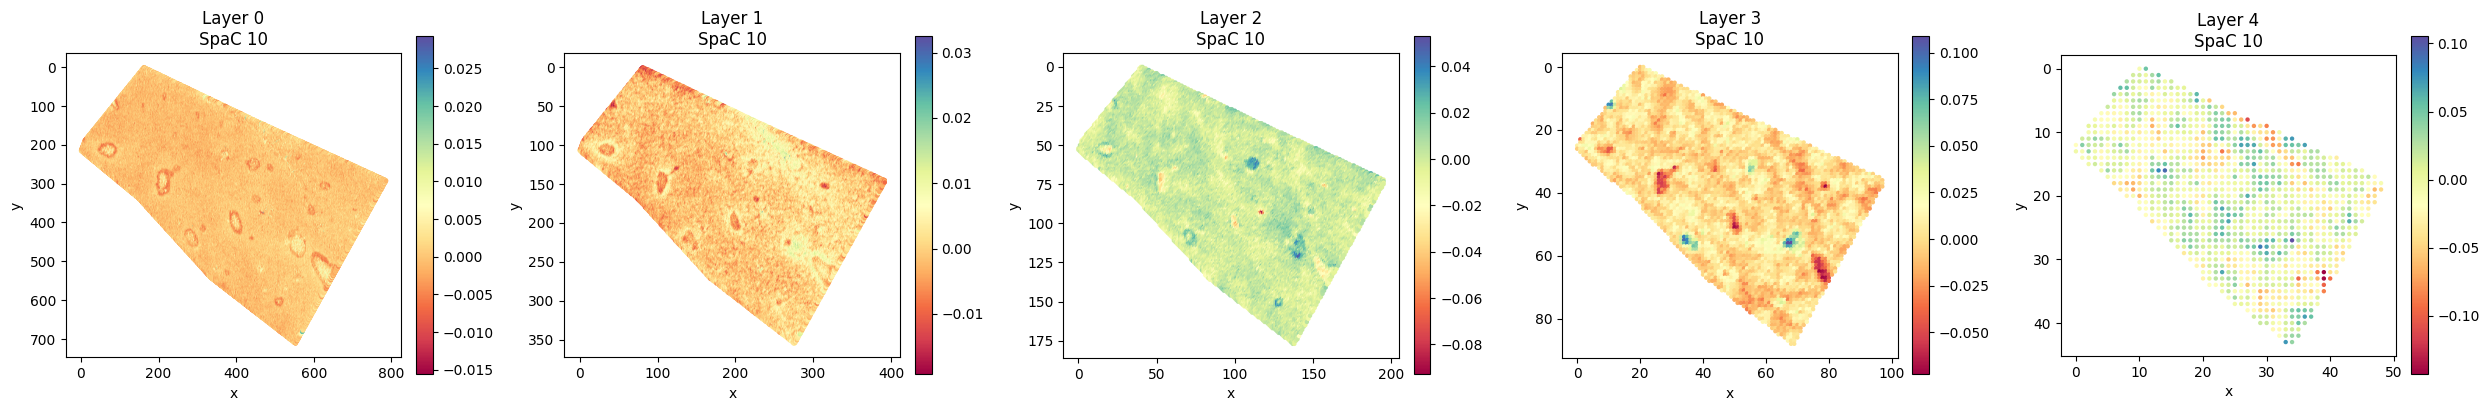

In [44]:
plot_first_spaco_per_level(
    levels=levels,
    result=result,
    component=9,   
    s=10,
    cmap="Spectral",
    invert_y=True  # optional
)